# 15 — Feature ablation (Phase 5d)

SHAP (notebook 12) told us *which features the model leans on*, correlationally. Ablation is the **causal** test: physically remove a feature group, retrain, and see whether accuracy actually moves. The result also **gates Phase 1.5** (the optional feature-expansion backlog) — should we add more features, or is that the wrong lever?

We split the 25 features into 5 behavioural families and run two complementary experiments on the **validation** fold (test stays untouched), each **averaged over 8 seeds** so we're reading real config differences, not LightGBM's run-to-run noise:

- **leave-one-group-out** — train on the other 4 families; how much does dropping this family cost?
- **only-this-group** — train on this family alone; how much signal does it carry by itself?

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from pipeline.features.run import FEATURE_COLS

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

GROUPS = {
    "Mouse kinematics": ["speed_mean", "speed_std", "accel_mean", "accel_std", "jitter"],
    "Mouse trajectory": ["mouse_curvature_mean", "mouse_curvature_std", "path_efficiency", "direction_changes_per_sec"],
    "Click dynamics": ["click_interval_mean", "click_interval_std", "click_reaction_mean", "inter_click_movement"],
    "Keyboard/typing": ["hold_mean", "hold_std", "iki_mean", "iki_std", "burst_rate", "wasd_rhythm", "keystroke_periodicity"],
    "Session aggregates": ["event_rate", "mouse_key_ratio", "active_time_pct", "scroll_count", "scroll_direction_ratio"],
}
assert sorted(c for g in GROUPS.values() for c in g) == sorted(FEATURE_COLS), "groups must cover all 25"

cfg = yaml.safe_load(open(ROOT / "configs" / "training.yaml"))
params = {k: v for k, v in cfg["lightgbm"].items() if k != "class_weight"}
train = pd.read_parquet(ROOT / "data" / "splits" / "train.parquet")
val = pd.read_parquet(ROOT / "data" / "splits" / "val.parquet")
le = LabelEncoder().fit(train["player"])
ytr = le.transform(train["player"])
yv = le.transform(val["player"])
N_SEEDS = 8
print(f"train={len(train)} windows | val={len(val)} windows | players={list(le.classes_)} | chance={1/len(le.classes_):.2f}")

train=187 windows | val=46 windows | players=['dninix', 'hydra', 'shotik'] | chance=0.33


In [2]:
def fit_eval(cols, n_seeds=N_SEEDS):
    # Mean +/- std validation accuracy over n_seeds LightGBM fits on `cols`.
    Xtr, Xv = train[cols].fillna(0.0), val[cols].fillna(0.0)
    accs = []
    for s in range(n_seeds):
        sc = StandardScaler().fit(Xtr)
        m = LGBMClassifier(**params, class_weight="balanced", random_state=s, verbose=-1)
        m.fit(sc.transform(Xtr), ytr)
        accs.append(accuracy_score(yv, m.predict(sc.transform(Xv))))
    return float(np.mean(accs)), float(np.std(accs))


full_acc, full_sd = fit_eval(FEATURE_COLS)
print(f"FULL model (all 25 features): val acc {full_acc:.3f} +/- {full_sd:.3f}")

FULL model (all 25 features): val acc 0.723 +/- 0.009


In [3]:
rows = []
for g, cols in GROUPS.items():
    remaining = [c for c in FEATURE_COLS if c not in cols]
    loo_acc, loo_sd = fit_eval(remaining)
    only_acc, only_sd = fit_eval(cols)
    rows.append({
        "group": g,
        "n_feat": len(cols),
        "only_group_acc": only_acc,
        "leave_out_acc": loo_acc,
        "drop_cost (full - LOO)": full_acc - loo_acc,
    })
abl = pd.DataFrame(rows).set_index("group").round(3)
abl

,n_feat,only_group_acc,leave_out_acc,drop_cost (full - LOO)
group,,,,
Mouse kinematics,5,0.793,0.810,-0.087
Mouse trajectory,4,0.671,0.707,0.016
Click dynamics,4,0.527,0.772,-0.049
Keyboard/typing,7,0.755,0.823,-0.101
Session aggregates,5,0.503,0.720,0.003


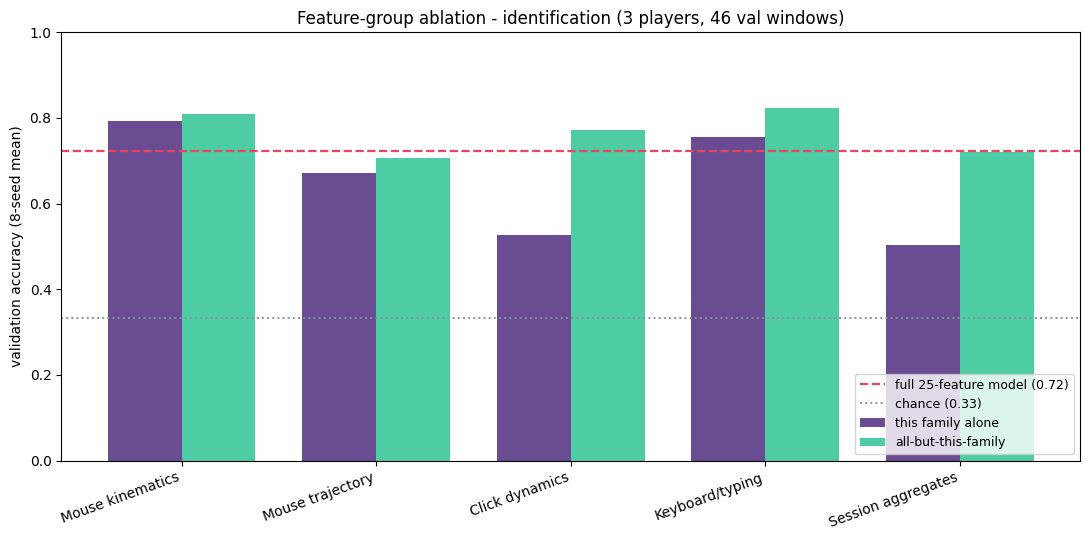

In [4]:
groups = list(GROUPS.keys())
x = np.arange(len(groups))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - w / 2, abl["only_group_acc"], w, color="#6a4c93", label="this family alone")
ax.bar(x + w / 2, abl["leave_out_acc"], w, color="#4ecca3", label="all-but-this-family")
ax.axhline(full_acc, color="#e94560", linestyle="--", linewidth=1.6, label=f"full 25-feature model ({full_acc:.2f})")
ax.axhline(1 / len(le.classes_), color="#8892a4", linestyle=":", linewidth=1.4, label=f"chance ({1/len(le.classes_):.2f})")
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=20, ha="right")
ax.set_ylabel("validation accuracy (8-seed mean)")
ax.set_title("Feature-group ablation - identification (3 players, 46 val windows)")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.0)
fig.tight_layout()
fig.savefig(FIG / "phase5d_ablation.png", dpi=110, bbox_inches="tight")
plt.show()

## Interpretation — and the Phase 1.5 decision

Two things jump out, and they point the same way:

1. **The fingerprint is redundant across families.** Several single families classify the 3 players well on their own (mouse kinematics and keyboard/typing each ≈ 0.75–0.79, far above the 0.33 chance line). No one family is *necessary* — the identity signal is encoded in many places at once.

2. **The full 25-feature model is over-parameterised at this N.** Dropping a whole family often *raises* validation accuracy above the full model: with only 187 train / 46 val windows, the extra correlated features add variance the model overfits. Smaller feature sets generalise better here.

**→ Phase 1.5 (feature expansion) is deferred — do not add features now.** Ablation is unambiguous: at 18 sessions the model already has *too many* features for the data, so adding more (flick detection, click-pattern features, FFT bands, …) would worsen overfitting, not help. The lever at this scale is **more recordings** (then re-run this ablation) or **feature reduction** — not feature addition. Phase 1.5 stays in the backlog, to be revisited only once a larger dataset makes the full feature set non-overfitting.

**Caveats (honest):** the 8-seed std is small (~0.01), so the *config* differences here are real for this split — but the validation fold is one split of a handful of sessions, so absolute deltas are split-specific. The qualitative conclusions (redundancy + over-parameterisation → defer 1.5) are robust; the exact accuracy numbers are not headline figures. Figure: `reports/figures/phase5d_ablation.png`.